In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md


/kaggle/input/datasets/samiullah9/roman-urdu-parallel-translation/Roman_Urdu_Parallel_Translation.csv


In [2]:
file_path = '/kaggle/input/datasets/samiullah9/roman-urdu-parallel-translation/Roman_Urdu_Parallel_Translation.csv'
df = pd.read_csv(file_path)

In [3]:
df.head(5)

,category,roman_urdu,urdu_script,translated_by_llm,translated_by_google
0,Health,mujhe bukhar hai,مجھے بخار ہے,I have a fever,I have a fever
1,Health,mera sir dard kar raha hai,میرا سر درد کر رہا ہے,My head hurts,I have a headache
2,Health,mujhe khansi hai,مجھے کھانسی ہے,I am coughing,I have a cough
3,Health,mera gala dard kar raha hai,میرا گلا درد کر رہا ہے,My throat hurts,My throat hurts
4,Health,mujhe pet dard hai,مجھے پیٹ درد ہے,I have a stomach ache,I have a stomach ache


In [4]:
df.columns

Index(['category', 'roman_urdu', 'urdu_script', 'translated_by_llm',
       'translated_by_google'],
      dtype='object')

In [5]:
roman_urdu_text = df['roman_urdu']

In [6]:
import string

# 1. Drop missing/NaN values and convert all items to string
clean_text = roman_urdu_text.dropna().astype(str)

# 2. Lowercase, strip punctuation, and normalize extra whitespaces
clean_text = (
    clean_text
    .str.lower()
    .str.translate(str.maketrans('', '', string.punctuation))
    .str.split()
    .str.join(' ')
)

# 3. Filter out any empty strings that resulted from cleaning
clean_text = clean_text[clean_text != '']

In [7]:
words = clean_text.str.split()

In [8]:
import re

def tokenize_word(word):
    # 1. Handle contractions (e.g., "don't" -> ["do", "n't"], "it's" -> ["it", "'s"])
    # Separates standard English apostrophe contractions while preserving the suffix structure
    word = re.sub(r"([a-zA-Z]+)(n't|'s|'ve|'ll|'re|'d|'m)\b", r"\1 \2", word, flags=re.IGNORECASE)
    
    # 2. Handle hyphenated words (e.g., "well-known" -> ["well", "-", "known"])
    # Splits hyphens into independent tokens
    word = re.sub(r"(\w+)-(\w+)", r"\1 - \2", word)
    
    # 3. Separate leading and trailing punctuation from word boundaries
    word = re.sub(r"^([^\w\s]+)", r"\1 ", word)  # Leading punctuation
    word = re.sub(r"([^\w\s]+)$", r" \1", word)  # Trailing punctuation
    
    return word.split()

# Apply the tokenization helper to every word across your dataset
tokenized_text = clean_text.apply(lambda text: [token for word in text.split() for token in tokenize_word(word)])

In [9]:
# Extract and flatten all tokens into a single list of word tokens T
T = [token for sentence in tokenized_text for token in sentence]

In [10]:
print(T[:400], end="")

['mujhe', 'bukhar', 'hai', 'mera', 'sir', 'dard', 'kar', 'raha', 'hai', 'mujhe', 'khansi', 'hai', 'mera', 'gala', 'dard', 'kar', 'raha', 'hai', 'mujhe', 'pet', 'dard', 'hai', 'mujhe', 'ulti', 'ho', 'rahi', 'hai', 'mujhe', 'chakkar', 'aa', 'rahe', 'hain', 'mera', 'badan', 'thak', 'gaya', 'hai', 'mujhe', 'sardee', 'lag', 'rahi', 'hai', 'mera', 'gala', 'sujan', 'hai', 'mujhe', 'saans', 'lene', 'mein', 'mushkil', 'hai', 'mera', 'pair', 'dard', 'kar', 'raha', 'hai', 'mera', 'haath', 'dard', 'kar', 'raha', 'hai', 'mujhe', 'allergy', 'ho', 'gayi', 'hai', 'mera', 'pet', 'phool', 'gaya', 'hai', 'mujhe', 'skin', 'rash', 'hai', 'mera', 'kamar', 'dard', 'kar', 'raha', 'hai', 'mujhe', 'thakan', 'mehsoos', 'ho', 'rahi', 'hai', 'mera', 'sir', 'bohat', 'tez', 'dard', 'kar', 'raha', 'hai', 'mujhe', 'pet', 'mein', 'jalan', 'hai', 'mujhe', 'nausea', 'ho', 'rahi', 'hai', 'mera', 'sir', 'ghoom', 'raha', 'hai', 'mujhe', 'aankh', 'laal', 'hai', 'mera', 'gala', 'khushk', 'hai', 'mujhe', 'muscle', 'pain', 'hai

## Zipf's Law

In [11]:
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Count word frequencies
word_counts = Counter(T)

# 2. Create DataFrame sorted by frequency in descending order
zipf_df = pd.DataFrame(word_counts.items(), columns=['word', 'frequency'])
zipf_df = zipf_df.sort_values(by='frequency', ascending=False).reset_index(drop=True)

# 3. Assign Ranks (1-indexed: 1 = most frequent)
zipf_df['rank'] = zipf_df.index + 1

# 4. Calculate Theoretical Zipf Frequency: f(r) = C / r  (where C = highest frequency)
C = zipf_df['frequency'].iloc[0]
zipf_df['theoretical_frequency'] = C / zipf_df['rank']

# Preview top 10 head words vs tail
print("--- Top 10 Head Words ---")
print(zipf_df.head(10))

print("\n--- Rare Tail Words ---")
print(zipf_df.tail(10))

--- Top 10 Head Words ---
     word  frequency  rank  theoretical_frequency
0     aur       3213     1               3213.000
1     hai       1934     2               1606.500
2    hain       1616     3               1071.000
3      ke       1261     4                803.250
4    liye       1047     5                642.600
5   mujhe        882     6                535.500
6   karna        764     7                459.000
7      ka        741     8                401.625
8   karte        688     9                357.000
9  rozana        672    10                321.300

--- Rare Tail Words ---
               word  frequency  rank  theoretical_frequency
3701        revisit          1  3702               0.867909
3702          duets          1  3703               0.867675
3703        respond          1  3704               0.867441
3704  relationships          1  3705               0.867206
3705             ہے          1  3706               0.866972
3706        cooking          1  3707   

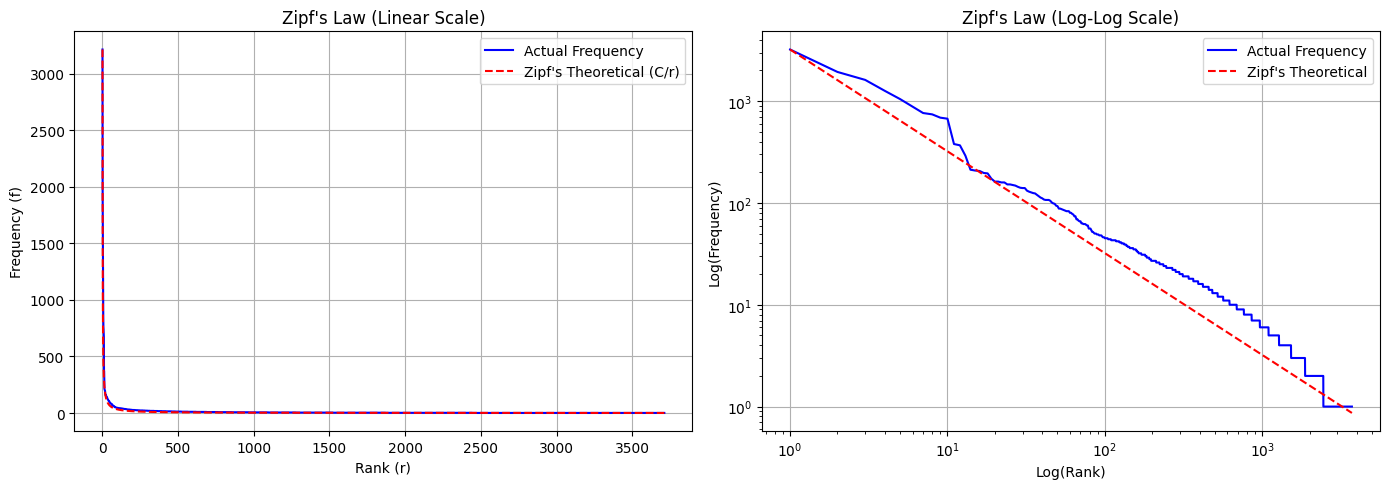

In [12]:
plt.figure(figsize=(14, 5))

# Plot 1: Linear Scale (shows the Long-Tail Distribution clearly)
plt.subplot(1, 2, 1)
plt.plot(zipf_df['rank'], zipf_df['frequency'], label='Actual Frequency', color='blue')
plt.plot(zipf_df['rank'], zipf_df['theoretical_frequency'], label="Zipf's Theoretical (C/r)", color='red', linestyle='--')
plt.title("Zipf's Law (Linear Scale)")
plt.xlabel("Rank (r)")
plt.ylabel("Frequency (f)")
plt.legend()
plt.grid(True)

# Plot 2: Log-Log Scale (Zipf's Law forms a straight line here)
plt.subplot(1, 2, 2)
plt.loglog(zipf_df['rank'], zipf_df['frequency'], label='Actual Frequency', color='blue')
plt.loglog(zipf_df['rank'], zipf_df['theoretical_frequency'], label="Zipf's Theoretical", color='red', linestyle='--')
plt.title("Zipf's Law (Log-Log Scale)")
plt.xlabel("Log(Rank)")
plt.ylabel("Log(Frequency)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
# Sample unseen test sentences (including punctuation, hyphens, and mixed cases)
test_sentences = [
    "Mujhe bukhar hai aur mera sir-dard kar raha hai!",
    "Don't worry, kya aap ko khansi hai?",
    "Yeh well-known medicine hai... jaldi le lo."
]

# Run through tokenizer
for sentence in test_sentences:
    # 1. Lowercase and normalize whitespace
    cleaned = (
        sentence.lower()
        .translate(str.maketrans('', '', string.punctuation))
        .strip()
    )
    
    # 2. Tokenize individual words using your tokenization rules
    tokens = [token for word in cleaned.split() for token in tokenize_word(word)]
    
    print(f"Original: {sentence}")
    print(f"Tokens:   {tokens}\n")

Original: Mujhe bukhar hai aur mera sir-dard kar raha hai!
Tokens:   ['mujhe', 'bukhar', 'hai', 'aur', 'mera', 'sirdard', 'kar', 'raha', 'hai']

Original: Don't worry, kya aap ko khansi hai?
Tokens:   ['dont', 'worry', 'kya', 'aap', 'ko', 'khansi', 'hai']

Original: Yeh well-known medicine hai... jaldi le lo.
Tokens:   ['yeh', 'wellknown', 'medicine', 'hai', 'jaldi', 'le', 'lo']



In [14]:
from collections import defaultdict, Counter

# Build bigram lookup dictionary: context_word -> Counter of next words
bigram_model = defaultdict(Counter)

for i in range(len(T) - 1):
    current_word = T[i]
    next_word = T[i + 1]
    bigram_model[current_word][next_word] += 1

In [15]:
def predict_next_word(current_word, top_k=3):
    current_word = current_word.lower().strip()
    
    if current_word not in bigram_model:
        return f"Word '{current_word}' not found in vocabulary."
    
    # Get the most common next words
    predictions = bigram_model[current_word].most_common(top_k)
    return predictions

# Test predicting the next word after "mera"
print("Next word after 'mera':", predict_next_word("mera"))
print("Next word after 'mujhe':", predict_next_word("mujhe"))
print("Next word after 'kar':", predict_next_word("kar"))

Next word after 'mera': [('sir', 30), ('badan', 21), ('pet', 16)]
Next word after 'mujhe': [('apne', 105), ('ek', 53), ('apna', 46)]
Next word after 'kar': [('raha', 40), ('liya', 22), ('li', 18)]


In [16]:
def predict_next_word_from_sentence(sentence, top_k=3):
    # 1. Tokenize the input sentence using your tokenization pipeline
    cleaned = sentence.lower().translate(str.maketrans('', '', string.punctuation)).strip()
    tokens = [token for word in cleaned.split() for token in tokenize_word(word)]
    
    if not tokens:
        return "Please enter a valid sentence."
    
    # 2. Get the last word to use as our current context
    last_word = tokens[-1]
    
    if last_word not in bigram_model:
        return f"Last word '{last_word}' not found in vocabulary."
    
    # 3. Calculate total occurrences of last_word to get probability distribution
    total_count = sum(bigram_model[last_word].values())
    top_predictions = bigram_model[last_word].most_common(top_k)
    
    # Format predictions with word & percentage probability
    results = [
        (word, count, f"{(count / total_count) * 100:.2f}%")
        for word, count in top_predictions
    ]
    
    print(f"Input Sentence: '{sentence}'")
    print(f"Context Word:   '{last_word}'")
    print(f"Predictions (Word, Count, Prob): {results}\n")

# --- Test with full sentences ---
predict_next_word_from_sentence("Mujhe bukhar")
predict_next_word_from_sentence("Mera gala dard kar")
predict_next_word_from_sentence("Main rozana")

Input Sentence: 'Mujhe bukhar'
Context Word:   'bukhar'
Predictions (Word, Count, Prob): [('hai', 3, '42.86%'), ('aur', 2, '28.57%'), ('ke', 2, '28.57%')]

Input Sentence: 'Mera gala dard kar'
Context Word:   'kar'
Predictions (Word, Count, Prob): [('raha', 40, '31.01%'), ('liya', 22, '17.05%'), ('li', 18, '13.95%')]

Input Sentence: 'Main rozana'
Context Word:   'rozana'
Predictions (Word, Count, Prob): [('urban', 23, '3.42%'), ('online', 21, '3.12%'), ('electric', 17, '2.53%')]

